In [8]:
import pandas as pd
import numpy as np
import os

In [22]:
def get_image_input(sim_no,output,r):
    import pandas as pd
    import numpy as np
    import os
    sim = 998
    nodes = 9271
    file = f'csv_files1/sim_w_comb_{sim_no}/S_U_PEEQ_COORD_{sim_no}.csv'
    if os.path.isfile(file):
       
        df = pd.read_csv(file)
        df = df.replace('       NoValue', np.nan)
        df.columns = df.columns.str.lstrip()
        x_cord = df['X']
        y_cord = df['Y']
        rho = np.zeros(len(y_cord))
        phi = np.zeros(len(y_cord))
        for i in range((len(x_cord))):
            rho[i] = np.sqrt(x_cord[i]**2 + y_cord[i]**2)
            phi[i] = np.arctan2(y_cord[i], x_cord[i])
        df['R'] = rho
        df['theta'] = phi
        df_data = df[(df['R'] > r-5) & (df['R'] < r+5)]
        df_data = df_data.astype({'PEEQ': float,'S-S11':float, 'S-S22':float, 'S-S33':float, 'S-S12':float})
        data_S11 = df_data['S-S11'].values
        data_S22 = df_data['S-S22'].values
        data_S33 = df_data['S-S33'].values
        data_S12 = df_data['S-S12'].values
        data_X = df_data['X'].values
        data_Y = df_data['Y'].values
        data_r = df_data['R'].values
        data_theta = df_data['theta'].values
        if output == 'sigmax':
            return (data_S11)
        if output == 'sigmay':
            return (data_S12)
        if output == 'sigmaz':
            return (data_S33)
        if output == 'r':
            return(data_r)
        if output == 'theta':
            return(data_theta)
        if output == 'x':
            return(data_X)
        if output == 'y':
            return(data_Y)
        

In [10]:
len1 = 128
len2 = 36

In [11]:
temp_in= []
temp_ex = []
for i in range(1000):
    file = f'csv_files/sim_w_comb_{i}/S_U_PEEQ_COORD_{i}.csv'
    if os.path.isfile(file):
        temp_in.append(i)
    else:
        temp_ex.append(i)
    

In [7]:
def get_xinput(r,len1):
    import numpy as np
    sim_count = len(temp_in)
    a = np.zeros((128,977))
    for i in range(len(temp_in)):
        a[:,i] = get_image_input(temp_in[i],'sigmax',r)
    return a
x_input = get_xinput(500,len)


In [12]:
def get_youtput(r,len2):
    import numpy as np
    sim_count = len(temp_in)
    a = np.zeros((36,977))
    for i in range(len(temp_in)):
        a[:,i] = get_image_input(temp_in[i],'sigmax',r)
    return a
y_output = get_youtput(700,len2)



In [13]:
y_output.shape

(36, 977)

In [14]:
x_input = x_input.reshape(977,128)
y_output = y_output.reshape(977,36)


# Implementing ML model (Random Forest)

In [15]:
# Spliting testing and training
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_input, y_output, test_size=0.2, random_state = 42)

In [16]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
regressor.fit(x_train, y_train)

RandomForestRegressor(n_estimators=10, random_state=0)

In [23]:
case = [16,134,198,312,401,632,708,795,866,987]
sigma_x = np.zeros((36,len(case)))
x1 = np.zeros((36,len(case)))
y1 = np.zeros((36,len(case)))
theta = np.zeros((128,len(case)))
for i in range(len(case)):
    sigma_x[:,i] = get_image_input(case[i],'sigmax',700)
    x1[:,i] = get_image_input(case[i],'x',700)
    y1[:,i] = get_image_input(case[i],'y',700)
    theta[:,i] = get_image_input(case[i],'theta',500)

In [24]:
theta.shape
x1[:,5]

array([-700.608 ,    0.    ,    0.    ,  700.608 , -699.866 , -695.7   ,
       -598.516 , -528.211 , -699.949 , -695.47  , -562.905 , -653.144 ,
       -625.73  , -278.719 ,  -56.7729, -113.363 , -370.559 ,  -56.5003,
       -112.609 , -250.534 ,  277.57  ,   56.5152,  112.641 ,   56.779 ,
        113.314 ,  413.611 ,  344.739 ,  699.948 ,  695.477 ,  595.105 ,
        657.669 ,  699.865 ,  695.695 ,  598.35  ,  605.861 ,  656.424 ])

In [27]:
theta = theta.reshape(10,128)
prediction = regressor.predict(theta)


In [28]:
x1 = x1.reshape(10,36)
y1 = y1.reshape(10,36)
sigma_x = sigma_x.reshape(10,36)
sigma_x.shape

(10, 36)

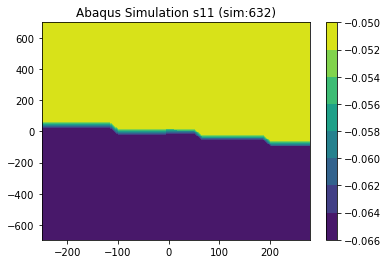

In [35]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

x = np.asarray(x1[5,:])
y = np.asarray(y1[5,:])
z = np.asarray(sigma_x[5,:])
z_sim = z.copy() 
xi = np.linspace(np.min(x), np.max(x), len(x))
yi = np.linspace(np.min(y), np.max(y), len(y))
X,Y= np.meshgrid(xi,yi)
Z = griddata((x, y), z, (X, Y),method='nearest')
plt.contourf(X,Y,Z)
plt.title("Abaqus Simulation s11 (sim:632)")
plt.colorbar()

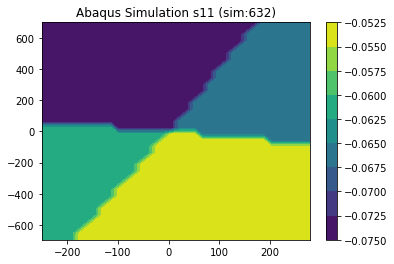

In [36]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

x = np.asarray(x1[5,:])
y = np.asarray(y1[5,:])
z = np.asarray(prediction[5])
z_ml = z.copy()
xi = np.linspace(np.min(x), np.max(x), len(x))
yi = np.linspace(np.min(y), np.max(y), len(y))

X,Y= np.meshgrid(xi,yi)
Z = griddata((x, y), z, (X, Y),method='nearest')
plt.contourf(X,Y,Z)
plt.title("Abaqus Simulation s11 (sim:632)")
plt.colorbar()

In [37]:
df_sim = pd.DataFrame({'X': x, "Y":y , "sigmax_randomforest":z_ml, "sigmax_sim":z_sim })
df_sim

,X,Y,sigmax_randomforest,sigmax_sim
0,-112.6090,-695.521,-0.054101,-0.065908
1,-112.6090,-695.521,-0.054081,-0.078560
2,-112.6090,-695.521,-0.045902,-0.051732
3,-112.6090,-695.521,-0.047785,-0.073978
4,-112.6090,-695.521,-0.049136,-0.074462
5,-112.6090,-695.521,-0.051619,-0.074842
6,-112.6090,-695.521,-0.053084,-0.039752
7,-112.6090,-695.521,-0.052651,-0.074320
8,-112.6090,-695.521,-0.053392,-0.047712
9,-112.6090,-695.521,-0.054760,-0.042198


In [47]:
from sklearn import metrics
mse = metrics.mean_squared_error(sigma_x, prediction)
mse

0.0006428412876095361